# K-Means Credit-Default Clustering Project

# ENVIRONMENT SETUP & DEPENDENCIES

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import uuid
import random
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility

# CONECTING TO LOCAL DW ATHENA
warnings.filterwarnings('ignore')

# --- config connection  ---
DB_USER = os.getenv("db_user")  # "usuario"
DB_PASS = os.getenv("db_pass")  # "senha"
DB_HOST = os.getenv("db_host")  # "host"
DB_PORT = os.getenv("db_port")  # "porta"
DB_NAME = os.getenv("db_name")  # "banco"

# Montagem da URI de conexão
ENGINE_URI = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Create the PostgreSQL Engine
engine = create_engine(ENGINE_URI)
SCHEMA_NAME = "kmeans"

np.random.seed(42)
random.seed(42)


# 1: DATA INGESTION & SYNTHETIC GENERATION (MOCK DDL & EXTRACT)
## Generating and Injecting Enterprise Data 
### -> toggle GENERATE_NEW_DATA to True to expand database size

In [2]:
# ==============================================================================
# PIPELINE CONFIGURATION & STATE CONTROL
# ==============================================================================
# SET TO True: Generates and appends new unique data into your tables.
# SET TO False: Bypasses data ingestion entirely and uses what is already in the DB.
GENERATE_NEW_DATA = True  

# Number of new members to inject per execution run
NEW_MEMBERS_TO_ADD = 500  

print(f"Pipeline State Control initialized. Generate new data: {GENERATE_NEW_DATA}")

# ==============================================================================
# PHASE 1: DYNAMIC DATA INGESTION (APPEND MODE)
# ==============================================================================
if GENERATE_NEW_DATA:
    print(f"\nExecuting Data Ingestion: Generating {NEW_MEMBERS_TO_ADD} new records...")
    
    # 1.1 Handle Static Product Dimension safely using native PostgreSQL logic
    # This prevents Primary Key duplication errors while keeping the dimension populated.
    products = [
        (1, 'Personal Loan', 'Retail', 0.115),
        (2, 'Credit Card', 'Retail', 0.140),
        (3, 'Overdraft', 'Retail', 0.155),
        (4, 'Agribusiness Credit', 'Agro', 0.085),
        (5, 'Commercial Loan', 'Corporate', 0.095),
        (6, 'Real Estate Financing', 'Mortgage', 0.070),
        (7, 'Vehicle Leasing', 'Asset Fin', 0.105)
    ]
    
    insert_product_sql = f"""
    INSERT INTO {SCHEMA_NAME}.dim_credit_products 
    (product_id, product_name, product_category, funding_cost_rate)
    VALUES (:id, :name, :cat, :rate)
    ON CONFLICT (product_id) DO NOTHING;
    """
    
    with engine.connect() as conn:
        for prod in products:
            conn.execute(text(insert_product_sql), {
                "id": prod[0], "name": prod[1], "cat": prod[2], "rate": prod[3]
            })
        conn.commit()
    print("-> dim_credit_products verified (Duplicates bypassed using ON CONFLICT).")

    # 1.2 Generate completely new, unique members
    new_member_ids = [str(uuid.uuid4()) for _ in range(NEW_MEMBERS_TO_ADD)]
    onboarding_dates = [datetime(2020, 1, 1) + timedelta(days=random.randint(0, 1800)) for _ in range(NEW_MEMBERS_TO_ADD)]

    df_new_members = pd.DataFrame({
        'member_id': new_member_ids,
        'onboarding_date': [d.strftime('%Y-%m-%d') for d in onboarding_dates],
        'member_type': np.random.choice(['Individual', 'Corporate'], size=NEW_MEMBERS_TO_ADD, p=[0.8, 0.2]),
        'credit_score_internal': np.random.randint(300, 1000, size=NEW_MEMBERS_TO_ADD),
        'central_bank_rating': np.random.choice(['A', 'B', 'C', 'D', 'E'], size=NEW_MEMBERS_TO_ADD, p=[0.5, 0.3, 0.12, 0.06, 0.02])
    })
    
    # Inject minimal artificial NULLs to maintain pipeline cleaning test integrity
    df_new_members.loc[df_new_members.sample(frac=0.02).index, 'credit_score_internal'] = np.nan
    
    # Append securely to the database
    df_new_members.to_sql('dim_members', engine, schema=SCHEMA_NAME, if_exists='append', index=False)
    print(f"-> {NEW_MEMBERS_TO_ADD} new members appended to dim_members.")

    # 1.3 Generate Operational Facts linked directly to these new members
    operations = []
    usage_records = []
    today = datetime(2026, 5, 22)

    for m_id in new_member_ids:
        num_prods = random.randint(1, 4)
        selected_prods = random.sample(range(1, 8), num_prods)
        
        for p_id in selected_prods:
            contracted = float(np.random.exponential(scale=50000)) + 5000
            outstanding = contracted * random.uniform(0.2, 0.95)
            
            base_tat = 72 if p_id in [4, 6] else 12
            tat = int(base_tat + np.random.normal(12, 6))
            
            dpd = 0
            if random.random() < 0.08:
                dpd = int(np.random.exponential(scale=45))
                
            if random.random() < 0.005:
                contracted = contracted * 50  
                
            operations.append({
                'operation_id': str(uuid.uuid4()),
                'member_id': m_id,
                'product_id': p_id,
                'origination_date': (today - timedelta(days=random.randint(30, 730))).strftime('%Y-%m-%d'),
                'maturity_date': (today + timedelta(days=random.randint(30, 1095))).strftime('%Y-%m-%d'),
                'contracted_amount': round(contracted, 2),
                'outstanding_balance': round(outstanding, 2),
                'nominal_interest_rate': round(random.uniform(0.08, 0.32), 4),
                'operational_tat_hours': max(1, tat),
                'days_past_due': dpd,
                'provision_for_credit_loss': round(outstanding * (0.02 if dpd == 0 else 0.15), 2)
            })
            
            usage_records.append({
                'snapshot_month': '2026-04-01',
                'member_id': m_id,
                'product_id': p_id,
                'total_limit': round(contracted * 1.2, 2),
                'utilized_limit_avg': round(outstanding, 2),
                'payment_delay_frequency': round(random.uniform(0, 0.4) if dpd > 0 else random.uniform(0, 0.05), 3)
            })

    pd.DataFrame(operations).to_sql('fact_credit_operations', engine, schema=SCHEMA_NAME, if_exists='append', index=False)
    pd.DataFrame(usage_records).to_sql('fact_product_usage_monthly', engine, schema=SCHEMA_NAME, if_exists='append', index=False)
    print("-> Fact records successfully appended.")
    print("Phase 1 Complete: Database volume expanded successfully.")
else:
    print("\nSkipping Data Ingestion. Execution configured to use current pre-existing database state.")

Pipeline State Control initialized. Generate new data: True

Executing Data Ingestion: Generating 500 new records...
-> dim_credit_products verified (Duplicates bypassed using ON CONFLICT).
-> 500 new members appended to dim_members.
-> Fact records successfully appended.
Phase 1 Complete: Database volume expanded successfully.


# 2. TRANSFORMATION AND 3. LOADING TO VIEW

In [3]:
# Analytical Datamart Processing Query
query_datamart = """
SELECT 
    m.member_id,
    m.credit_score_internal,
    COUNT(DISTINCT op.product_id) AS active_products_count,
    SUM(op.outstanding_balance) AS total_exposure,
    AVG(op.contracted_amount) AS avg_ticket_size,
    SUM(op.outstanding_balance * op.nominal_interest_rate) / NULLIF(SUM(op.outstanding_balance), 0) AS weighted_avg_interest_rate,
    MAX(op.days_past_due) AS max_days_past_due,
    SUM(op.provision_for_credit_loss) / NULLIF(SUM(op.outstanding_balance), 0) AS expected_loss_rate,
    AVG(op.operational_tat_hours) AS avg_operational_tat_hours,
    AVG(u.payment_delay_frequency) AS avg_payment_delay_freq
FROM kmeans.dim_members m
LEFT JOIN kmeans.fact_credit_operations op ON m.member_id = op.member_id 
LEFT JOIN kmeans.fact_product_usage_monthly u ON m.member_id = u.member_id AND u.product_id = op.product_id
GROUP BY m.member_id, m.credit_score_internal;
"""

df_raw_dm = pd.read_sql(query_datamart, engine)

print(f"Raw Datamart View Shape: {df_raw_dm.shape}")

# Data Cleaning & Outlier Mitigation (Senior Engineering Principles)
# 1. Handle Nulls in Credit Score via median imputation
credit_score_median = df_raw_dm['credit_score_internal'].median()
df_raw_dm['credit_score_internal'] = df_raw_dm['credit_score_internal'].fillna(credit_score_median)

# 2. Treat Outliers via Tukey's Method (IQR) for exposure metric to avoid K-Means center skew
Q1 = df_raw_dm['total_exposure'].quantile(0.25)
Q3 = df_raw_dm['total_exposure'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

# Clip outliers to the upper bound instead of dropping them, retaining member value footprint
df_cleaned_dm = df_raw_dm.copy()
df_cleaned_dm['total_exposure'] = np.where(df_cleaned_dm['total_exposure'] > upper_bound, upper_bound, df_cleaned_dm['total_exposure'])
df_cleaned_dm = df_cleaned_dm.dropna() # Drop remaining analytical residuals if any

# Write the treated data back to a physical "Materialized Table" for analytics execution
df_cleaned_dm.to_sql(
    'mat_view_cleaned_credit_analytics', 
    engine, 
    schema=SCHEMA_NAME, 
    if_exists='replace', 
    index=False
)
print("Phase 2 & 3 Complete: Cleaned and loaded to mat_view_cleaned_credit_analytics table.")


Raw Datamart View Shape: (4500, 10)
Phase 2 & 3 Complete: Cleaned and loaded to mat_view_cleaned_credit_analytics table.


# 4. K-MEANS CLUSTERING
## Cluster Analysis: Risk-Yield Frontier

The portfolio segmentation via clustering algorithms identified four distinct operational and risk profiles. This analysis evaluates the relationship between the weighted average interest rate (`weighted_avg_interest_rate`) and the maximum observed delinquency (`max_days_past_due`), measuring asset distribution against the **Critical NPL threshold (15+ ~ 90+ DPD)**.

---

### 1. Cluster 0: High Yield / High Risk (Leveraged Operations)
*   **Observed Behavior:** Concentrates assets positioned in the upper-right quadrant of the frontier. It features aggressive interest rates coupled with high data dispersion and a significant density of points breaching the 90 DPD critical ceiling.
*   **Strategic Significance:** Represents the portfolio's nominal yield leverage. While maximizing initial gross margins, it introduces substantial cash flow volatility due to high credit carrying costs and elevated provisioning requirements (PELD/ECL).
*   **Recommended Action:** Mitigate risk by establishing strict concentration limits per vintage and tightening credit scoring models for new entrants in this bracket.

### 2. Cluster 1: Core Portfolio / Low Risk (Prime Profile)
*   **Observed Behavior:** A highly homogeneous cluster located primarily in the lower-left quadrant. Interest rates are moderate-to-low, and delinquency remains tightly controlled, showing virtually no breaches of the 90 DPD critical threshold.
*   **Strategic Significance:** Serves as the foundation for liquidity, stability, and operational sustainability. It ensures highly predictable cash flows with minimal regulatory capital consumption due to a low Probability of Default (PD).
*   **Recommended Action:** Target this segment for retention strategies, relationship expansion, and high-volume asset origination.

### 3. Cluster 2: Mispriced Assets (Underpriced Risk)
*   **Observed Behavior:** The most critical red flag in the mapping. It identifies contracts that carry low interest rates—insufficient to cover the appropriate risk premium—yet exhibit intermediate-to-severe delinquency behavior.
*   **Strategic Significance:** Destroys marginal value. The financial return generated by this group fails to statistically compensate for the expected loss and operational collection costs, leading to portfolio inefficiency.
*   **Recommended Action:** Initiate an immediate review of the pricing policy and tighten eligibility criteria in the credit underwriting pipeline for this specific risk profile.

### 4. Cluster 3: Structured Operations / Controlled Risk
*   **Observed Behavior:** Assets located in the upper-mid interest rate quadrant. They exhibit short-term volatility (recurrent early-stage delinquency) but demonstrate a strong recovery trend before consolidating into permanent losses at the Critical NPL line.
*   **Strategic Significance:** The quadrant of highest marginal efficiency. It provides the optimal trade-off between the charged spread and the actual net loss realized after asset recovery efforts.
*   **Recommended Action:** Maintain proactive monitoring and evaluate a controlled increase in exposure to this segment to optimize the overall portfolio return.

In [4]:
# Pull columns designated for statistical scaling
features = [
    'credit_score_internal', 'active_products_count', 'total_exposure', 
    'weighted_avg_interest_rate', 'max_days_past_due', 
    'expected_loss_rate', 'avg_operational_tat_hours', 'avg_payment_delay_freq'
]

X = df_cleaned_dm[features].values

# standard scale features since K-Means uses Euclidean distances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hyperparameter optimization: Verify Silhouette Score for K=4 clusters
k_clusters = 4
kmeans = KMeans(n_clusters=k_clusters, init='k-means++', max_iter=500, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Append results back to dataset
df_cleaned_dm['cluster'] = cluster_labels
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"K-Means modeling complete. Silhouette Coefficient for K={k_clusters}: {sil_score:.4f}")

K-Means modeling complete. Silhouette Coefficient for K=4: 0.2074


# PHASE 5: DATA ANALYSIS & CALCULATING CLUSTER PROFILES

In [5]:
cluster_profiles = df_cleaned_dm.groupby('cluster').agg({
    'member_id': 'count',
    'credit_score_internal': 'mean',
    'active_products_count': 'mean',
    'total_exposure': 'mean',
    'weighted_avg_interest_rate': 'mean',
    'max_days_past_due': 'mean',
    'avg_operational_tat_hours': 'mean'
}).rename(columns={'member_id': 'member_count'})

# Format percentages and values for presentation
cluster_profiles['weighted_avg_interest_rate'] = (cluster_profiles['weighted_avg_interest_rate'] * 100).round(2).astype(str) + '%'
cluster_profiles['total_exposure'] = 'R$ ' + cluster_profiles['total_exposure'].round(2).astype(str)
cluster_profiles['credit_score_internal'] = cluster_profiles['credit_score_internal'].round(0)
cluster_profiles['active_products_count'] = cluster_profiles['active_products_count'].round(2)
cluster_profiles['max_days_past_due'] = cluster_profiles['max_days_past_due'].round(1)
cluster_profiles['avg_operational_tat_hours'] = cluster_profiles['avg_operational_tat_hours'].round(1)

print("\n--- FINAL COMPUTED CLUSTER METRICS ---")
print(cluster_profiles.to_string())


--- FINAL COMPUTED CLUSTER METRICS ---
         member_count  credit_score_internal  active_products_count total_exposure weighted_avg_interest_rate  max_days_past_due  avg_operational_tat_hours
cluster                                                                                                                                                    
0                1817                  641.0                   3.53   R$ 120976.25                     20.03%                3.1                       40.7
1                 894                  648.0                   1.89    R$ 44723.56                     18.34%                0.4                       64.7
2                1349                  643.0                   1.56    R$ 39948.54                     19.97%                0.5                       24.2
3                 440                  660.0                   2.62    R$ 69876.39                     20.33%               64.2                       37.4


# PHASE 6: DATA ANALYSIS AND BUSINESS INTELLIGENCE 

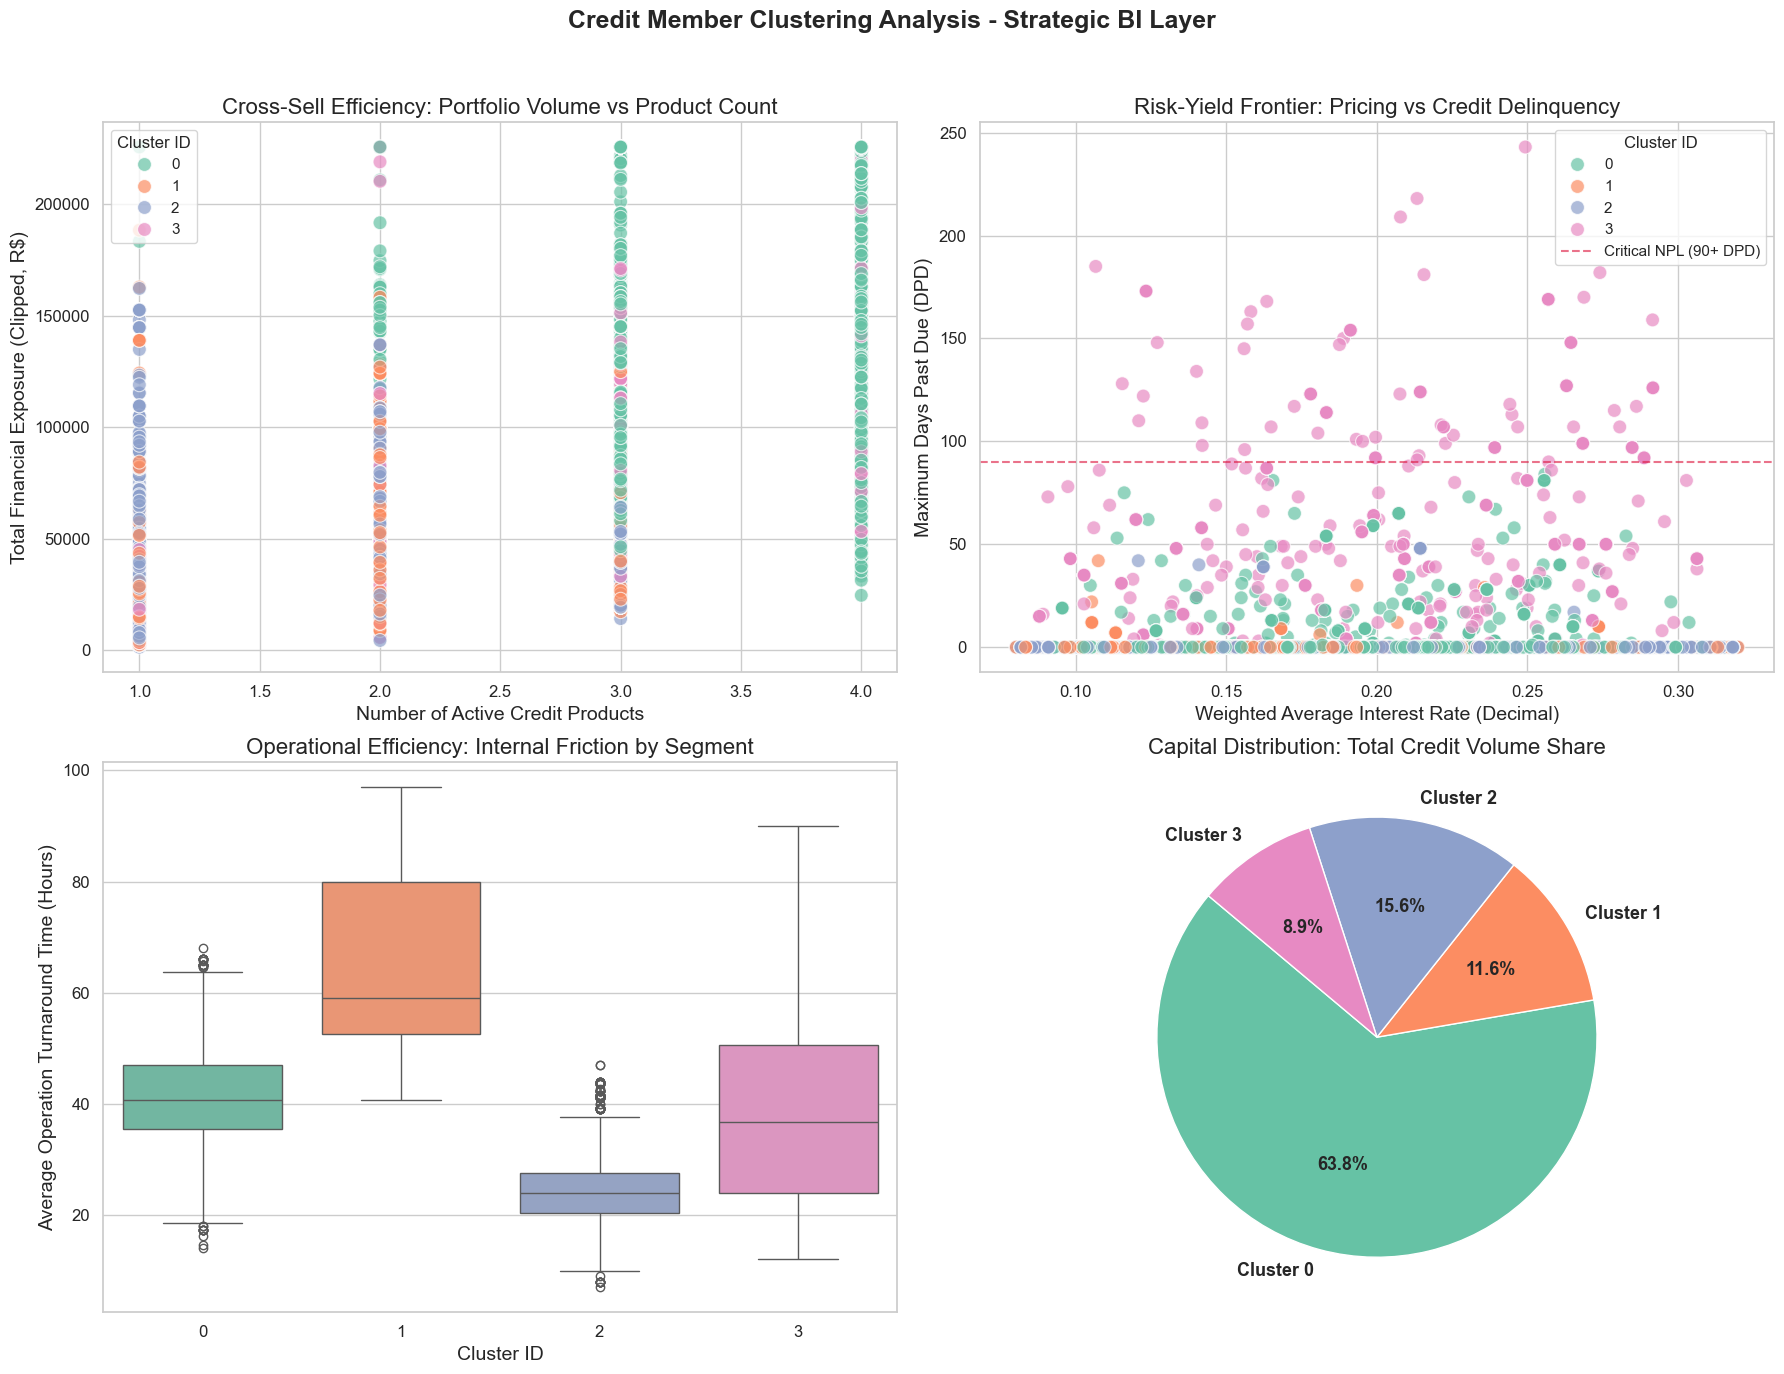

In [6]:
 # Set advanced plotting aesthetics for executive presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

# Create a multi-plot figure grid (2x2 Layout)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Credit Member Clustering Analysis - Strategic BI Layer', fontweight='bold', y=0.98)

# ------------------------------------------------------------------------------
# PLOT 1: Product Diversification vs. Total Exposure (The Cross-Sell Canvas)
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=df_cleaned_dm, 
    x='active_products_count', 
    y='total_exposure', 
    hue='cluster', 
    palette='Set2', 
    alpha=0.7, 
    edgecolor='w', 
    s=100, 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Cross-Sell Efficiency: Portfolio Volume vs Product Count')
axes[0, 0].set_xlabel('Number of Active Credit Products')
axes[0, 0].set_ylabel('Total Financial Exposure (Clipped, R$)')
axes[0, 0].legend(title='Cluster ID', loc='upper left')

# ------------------------------------------------------------------------------
# PLOT 2: Risk-Yield Mapping (Interest Rate vs Delinquency)
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=df_cleaned_dm, 
    x='weighted_avg_interest_rate', 
    y='max_days_past_due', 
    hue='cluster', 
    palette='Set2', 
    alpha=0.7, 
    edgecolor='w', 
    s=100, 
    ax=axes[0, 1]
)
# Render operational pricing threshold (e.g., historical maximum risk ceiling)
axes[0, 1].axhline(y=90, color='crimson', linestyle='--', alpha=0.6, label='Critical NPL (90+ DPD)')
axes[0, 1].set_title('Risk-Yield Frontier: Pricing vs Credit Delinquency')
axes[0, 1].set_xlabel('Weighted Average Interest Rate (Decimal)')
axes[0, 1].set_ylabel('Maximum Days Past Due (DPD)')
axes[0, 1].legend(title='Cluster ID')

# ------------------------------------------------------------------------------
# PLOT 3: Operational Friction Analysis (Turnaround Time Distribution)
# ------------------------------------------------------------------------------
sns.boxplot(
    data=df_cleaned_dm, 
    x='cluster', 
    y='avg_operational_tat_hours', 
    palette='Set2', 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Operational Efficiency: Internal Friction by Segment')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Average Operation Turnaround Time (Hours)')

# ------------------------------------------------------------------------------
# PLOT 4: Financial Value Concentration (Total Volume Contribution)
# ------------------------------------------------------------------------------
cluster_volumes = df_cleaned_dm.groupby('cluster')['total_exposure'].sum().reset_index()
axes[1, 1].pie(
    cluster_volumes['total_exposure'], 
    labels=[f'Cluster {int(i)}' for i in cluster_volumes['cluster']],
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('Set2', n_colors=k_clusters),
    textprops={'fontsize': 13, 'weight': 'bold'}
)
axes[1, 1].set_title('Capital Distribution: Total Credit Volume Share')

# Optimize layout structure and render
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

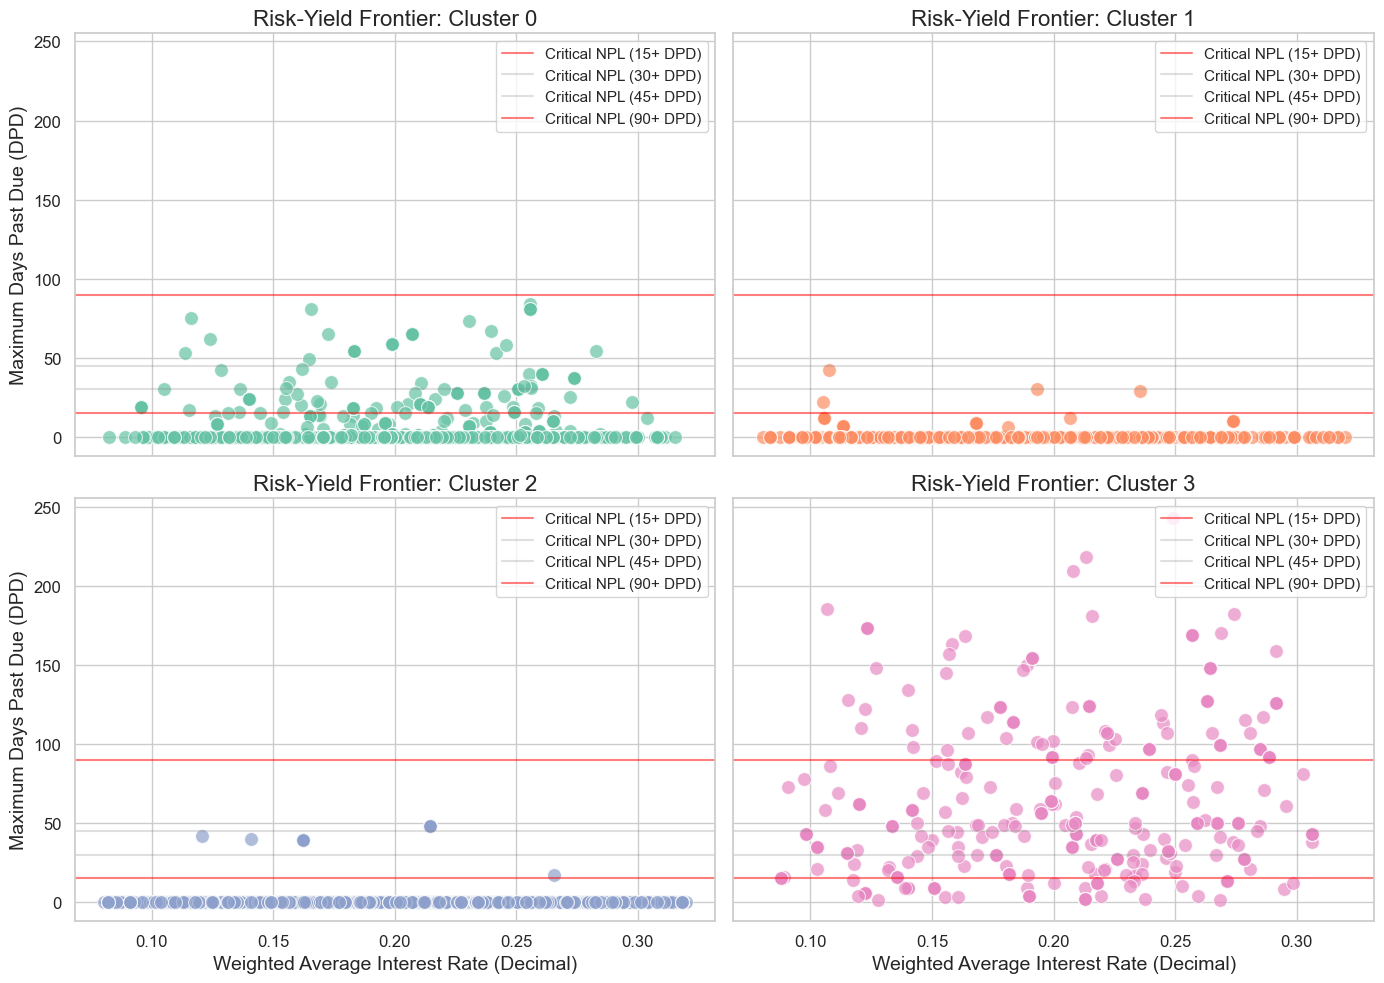

|   cluster |   qtd_operacoes |   taxa_media |   dpd_max_medio |   percentual_npl_15 |   percentual_npl_30 |   percentual_npl_45 |   percentual_npl_90 |   representatividades_pct |
|----------:|----------------:|-------------:|----------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------------:|
|    0.0000 |       1817.0000 |       0.2003 |          3.0936 |              7.4298 |              3.1921 |              1.9813 |              0.0000 |                   40.3778 |
|    1.0000 |        894.0000 |       0.1834 |          0.4128 |              0.4474 |              0.1119 |              0.0000 |              0.0000 |                   19.8667 |
|    2.0000 |       1349.0000 |       0.1997 |          0.4603 |              1.1119 |              1.0378 |              0.4448 |              0.0000 |                   29.9778 |
|    3.0000 |        440.0000 |       0.2033 |         64.1977 |             85.0000 |         

In [7]:
# Configuração da figura com uma grade 2x2 para os 4 clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Lista com os identificadores dos 4 clusters (ajuste os nomes se forem strings)
clusters = [0, 1, 2, 3]

# Mapeamento de cores baseado na paleta original 'Set2' para manter a consistência
palette = sns.color_palette('Set2', len(clusters))

# Achatar a matriz de eixos para facilitar a iteração em um único loop
axes_flat = axes.flatten()

for i, cluster_id in enumerate(clusters):
    ax = axes_flat[i]
    
    # Filtragem dos dados especificamente para o cluster atual
    cluster_data = df_cleaned_dm[df_cleaned_dm['cluster'] == cluster_id]
    
    # Geração do scatter plot para o cluster individual
    sns.scatterplot(
        data=cluster_data, 
        x='weighted_avg_interest_rate', 
        y='max_days_past_due', 
        color=palette[i], 
        alpha=0.7, 
        edgecolor='w', 
        s=100, 
        ax=ax
    )
    
    # Inclusão do limite operacional de inadimplência (Critical NPL)
    ax.axhline(y=15, color='red', linestyle='-', alpha=0.5, label='Critical NPL (15+ DPD)')
    ax.axhline(y=30, color='gray', linestyle='-', alpha=0.25, label='Critical NPL (30+ DPD)')
    ax.axhline(y=45, color='gray', linestyle='-', alpha=0.25, label='Critical NPL (45+ DPD)')
    ax.axhline(y=90, color='red', linestyle='-', alpha=0.5, label='Critical NPL (90+ DPD)')
    
    # Títulos e rótulos específicos por quadrante
    ax.set_title(f'Risk-Yield Frontier: Cluster {cluster_id}')
    ax.set_xlabel('Weighted Average Interest Rate (Decimal)')
    ax.set_ylabel('Maximum Days Past Due (DPD)')
    ax.legend(loc='upper right')

# Ajuste do layout para evitar sobreposição de elementos textuais
plt.tight_layout()
plt.show()



# Consolidação estatística por cluster
resumo_clusters = df_cleaned_dm.groupby('cluster').agg(
    qtd_operacoes=('cluster', 'count'),
    taxa_media=('weighted_avg_interest_rate', 'mean'),
    dpd_max_medio=('max_days_past_due', 'mean'),
    percentual_npl_15=('max_days_past_due', lambda x: (x > 15).mean() * 100),
    percentual_npl_30=('max_days_past_due', lambda x: (x > 30).mean() * 100),
    percentual_npl_45=('max_days_past_due', lambda x: (x > 45).mean() * 100),
    percentual_npl_90=('max_days_past_due', lambda x: (x > 90).mean() * 100)
).reset_index()

# Cálculo da representatividade (volumetria)
total_ops = resumo_clusters['qtd_operacoes'].sum()
resumo_clusters['representatividades_pct'] = (resumo_clusters['qtd_operacoes'] / total_ops) * 100

# CORREÇÃO: Utilizar floatfmt em vez de float_format
print(resumo_clusters.to_markdown(index=False, floatfmt=".4f"))